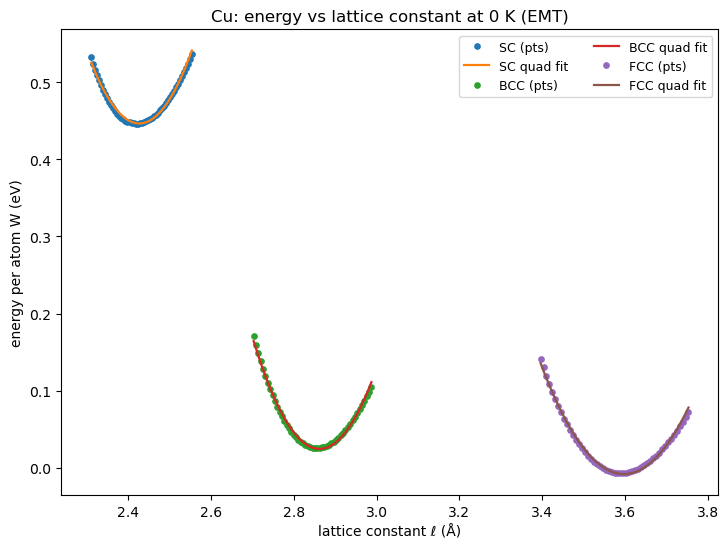

Quadratic fit in a fine window:  W(ℓ) = p0 + p1 ℓ + p2 ℓ^2   (energies in eV, ℓ in Å)
Struct          p0          p1          p2    ℓ0_q (Å) W0_q (eV/atom)
SC       34.937765  -28.428586    5.857862      2.4265      0.446322
BCC      45.184985  -31.556721    5.512708      2.8622      0.024481
FCC      45.829728  -25.480980    3.541178      3.5978     -0.008151

Lowest-energy structure (EMT): FCC with ℓ0 ≈ 3.5978 Å.
Literature ~3.615 Å: Δ = -0.0172 Å (-0.48%).


In [48]:
# Task 3.2

import numpy as np
import matplotlib.pyplot as plt

from ase.build import bulk
from ase.calculators.emt import EMT

# Inputs and starting parameters
radius_pm = 128.0          # atomic radius a for Cu in pm
r_A = radius_pm * 0.01     # Å

# geometry-based guesses from (closest-packed arguments)
l_guess = {
    'sc' : 2.0 * r_A,                   # ℓ ≈ 2 a
    'bcc': 4.0 * r_A / np.sqrt(3.0),
    'fcc': 2.0 * np.sqrt(2.0) * r_A
}

# coarse scan settings (to bracket the minimum reliably)
coarse_rel_span = 0.15     # ±15% around guess
coarse_npoints  = 25

# fine window (local refinement around the best coarse point)
fine_rel_span = 0.05       # ±5% around the coarse minimum
fine_npoints  = 51

# Define arrays L (Å), W_per_atom (eV) for given cubic structure
def energy_vs_lattice(structure, element='Cu', l0=None, rel_span=0.15, n=15):
    """
    Sample total energy and per-atom energy for a cubic structure over a range of 'a' (Å).
    """
    if l0 is None:
        raise ValueError("Provide an initial lattice guess l0 (Å).")
    L = np.linspace((1-rel_span)*l0, (1+rel_span)*l0, n)
    E = np.zeros_like(L)
    V = np.zeros_like(L)
    N = None
    for i, l in enumerate(L):
        atoms = bulk(element, structure, a=l, cubic=True)
        atoms.calc = EMT()
        E[i] = atoms.get_potential_energy()  # eV total
        V[i] = atoms.get_volume()            # Å^3
        if N is None:
            N = len(atoms)
    W = E / N                                # eV/atom
    return L, E, W, V, N

# Fit W(ℓ) = p0 + p1 ℓ + p2 ℓ^2.
def fit_quadratic(L, W):
    p2, p1, p0 = np.polyfit(L, W, deg=2)
    lmin = -p1 / (2.0 * p2)
    Wmin = p0 + p1*lmin + p2*lmin*lmin
    return (p0, p1, p2), lmin, Wmin

results = {}
plt.figure(figsize=(7.4, 5.6))

# Loop using the starting parameters
for struct, l0 in l_guess.items():
    # Coarse scan to bracket the minimum
    Lc, Ec, Wc, Vc, N = energy_vs_lattice(struct, 'Cu', l0=l0,
                                          rel_span=coarse_rel_span, n=coarse_npoints)
    l_center = Lc[np.argmin(Wc)]

    # Fine scan near the minimum (better conditioning of quadratic fit)
    Lf, Ef, Wf, Vf, _ = energy_vs_lattice(struct, 'Cu', l0=l_center,
                                          rel_span=fine_rel_span, n=fine_npoints)

    # Quadratic fit
    (p0, p1, p2), lmin_q, Wmin_q = fit_quadratic(Lf, Wf)

    # Record
    results[struct] = dict(
        p0=p0, p1=p1, p2=p2,
        lmin_q=lmin_q, Wmin_q=Wmin_q,
        L=Lc, W=Wc, Lf=Lf, Wf=Wf
    )

    # Plot: points + local quadratic fit
    plt.plot(Lf, Wf, 'o', ms=3.8, label=f'{struct.upper()} (pts)')
    Lfit = np.linspace(Lf.min(), Lf.max(), 300)
    Wfit = p0 + p1*Lfit + p2*(Lfit**2)
    plt.plot(Lfit, Wfit, '-', lw=1.6, label=f'{struct.upper()} quad fit')

plt.xlabel('lattice constant ℓ (Å)')
plt.ylabel('energy per atom W (eV)')
plt.title('Cu: energy vs lattice constant at 0 K (EMT)')
plt.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# Summary table
print("Quadratic fit in a fine window:  W(ℓ) = p0 + p1 ℓ + p2 ℓ^2   (energies in eV, ℓ in Å)")
print("{:<6s} {:>11s} {:>11s} {:>11s}   {:>9s} {:>13s}".format(
    "Struct", "p0", "p1", "p2", "ℓ0_q (Å)", "W0_q (eV/atom)"))

for struct in ("sc","bcc","fcc"):
    r = results[struct]
    print("{:<6s} {:>11.6f} {:>11.6f} {:>11.6f}   {:>9.4f} {:>13.6f}".format(
        struct.upper(), r['p0'], r['p1'], r['p2'], r['lmin_q'], r['Wmin_q']))

# Compare best lattice to literature (~0 K copper ≈ 3.615 Å)
best_struct = min(results, key=lambda k: results[k]['Wmin_q'])
best_l0 = results[best_struct]['lmin_q']
lit = 3.615  # Å
err_pct = (best_l0 - lit)/lit*100
print(f"\nLowest-energy structure (EMT): {best_struct.upper()} with ℓ0 ≈ {best_l0:.4f} Å.")
print(f"Literature ~{lit:.3f} Å: Δ = {best_l0 - lit:+.4f} Å ({err_pct:+.2f}%).")


fcc Cu @ 0 K (EMT) — Elastic constants via energy–strain fits
Units: 10^11 N/m^2 (Table 1)  — reference values in parentheses.

C11 =   1.7166   (ref 1.7620)   err =  -2.58%
C12 =   1.1617   (ref 1.2494)   err =  -7.02%
C44 =   0.8684   (ref 0.8177)   err =  +6.21%


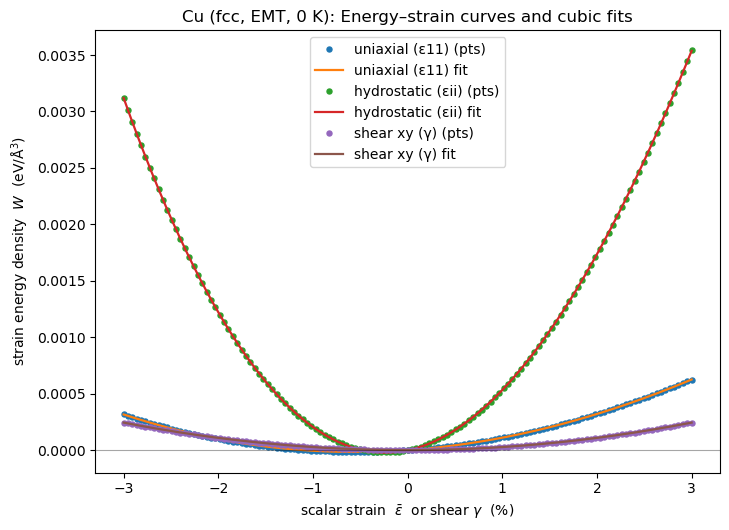

In [46]:
# Task 3.5
from ase.optimize import BFGS

# Cubic fit and derivatives
def fit_cubic(x, y):
    """
    Fit y(x) ~ a x^3 + b x^2 + c x + d and return coefficients,
    the stationary point nearest x=0, and the second derivative there.
    """
    a, b, c, d = np.polyfit(x, y, deg=3)
    roots = np.roots([3*a, 2*b, c])                 # y' = 3 a x^2 + 2 b x + c
    real_roots = roots[np.isreal(roots)].real
    x_min = real_roots[np.argmin(np.abs(real_roots))] if len(real_roots) else 0.0
    d2y = 6*a*x_min + 2*b                            # y''(x_min)
    return (a, b, c, d), x_min, d2y

def deform_cell(cell0, eps):
    # new_cell = cell0 @ (I + eps)
    return cell0 @ (np.eye(3) + eps)

# Reference fcc state from Task 3.2
if 'fcc' not in results:
    raise RuntimeError("Task 3.2 results not found. Run the first cell to create `results['fcc']`.")

l0 = results['fcc'].get('lmin_c', results['fcc']['lmin_q'])

# Build relaxed reference at l0, then positions-only relax
atoms0 = bulk('Cu', 'fcc', a=l0, cubic=True)
atoms0.calc = EMT()

dyn0 = BFGS(atoms0, logfile=None)
dyn0.run(fmax=1e-6, steps=200)

E0 = atoms0.get_potential_energy()   # eV (total)
V0 = atoms0.get_volume()             # Å^3
cell0 = atoms0.get_cell().array.copy()

# Strain paths
# Path A (uniaxial): epsilon = diag(eps, 0, 0)  -> d2W/dε^2 = C11
def eps_uniax(eps):
    M = np.zeros((3,3)); M[0,0] = eps; return M

# Path B (hydrostatic): epsilon = diag(eps, eps, eps) -> d2W/dε^2 = 3 (C11 + 2 C12)
def eps_hydro(eps):
    M = np.zeros((3,3)); M[0,0] = eps; M[1,1] = eps; M[2,2] = eps; return M

# Path C (simple shear γ in xy): ε12 = γ/2, ε21 = γ/2  -> d2W/dγ^2 = C44
def eps_shear_xy(gamma):
    M = np.zeros((3,3)); M[0,1] = 0.5*gamma; M[1,0] = 0.5*gamma; return M

paths = {
    "uniaxial (ε11)": eps_uniax,
    "hydrostatic (εii)": eps_hydro,
    "shear xy (γ)": eps_shear_xy
}

# Sampling (small strains in elastic regime)
span  = 0.03    # ±1.0%
npts  = 131
grid  = np.linspace(-span, span, npts)

curves = {}
for label, eps_fun in paths.items():
    X, W = [], []
    for s in grid:
        # fresh copy each time
        atoms = bulk('Cu', 'fcc', a=l0, cubic=True)
        atoms.calc = EMT()
        # affine cell deformation and consistent scaling of positions
        new_cell = deform_cell(cell0, eps_fun(s))
        atoms.set_cell(new_cell, scale_atoms=True)
        E = atoms.get_potential_energy()
        W.append((E - E0) / V0)   # strain energy density (eV/Å^3)
        X.append(s)

    X = np.array(X); W = np.array(W)
    curves[label] = (X, W)

# Fit cubic, extract curvatures, compose elastic constants
fits = {}
for label, (X, W) in curves.items():
    (a,b,c,d), x_min, d2W = fit_cubic(X, W)
    fits[label] = dict(a=a,b=b,c=c,d=d, x_min=x_min, d2W=d2W)

# From derivations:
#   Path A: d2W = C11
C11_eVA3 = fits["uniaxial (ε11)"]["d2W"]
#   Path B: d2W = 3 (C11 + 2 C12)  → C12 = ( d2W_B / 3 - C11 ) / 2
d2W_hyd  = fits["hydrostatic (εii)"]["d2W"]
C12_eVA3 = (d2W_hyd / 3.0 - C11_eVA3) / 2.0
#   Path C: d2W = C44
C44_eVA3 = fits["shear xy (γ)"]["d2W"]

# Convert eV/Å^3 → 10^11 N/m^2
conv = 1.6021766208
C11 = C11_eVA3 * conv
C12 = C12_eVA3 * conv
C44 = C44_eVA3 * conv

# Literature @ 0 K (units: 10^11 N/m^2)
C11_lit, C12_lit, C44_lit = 1.7620, 1.2494, 0.8177
pct_err = lambda val, ref: (val - ref)/ref * 100.0

print("fcc Cu @ 0 K (EMT) — Elastic constants via energy–strain fits")
print("Units: 10^11 N/m^2 (Table 1)  — reference values in parentheses.\n")
print(f"C11 = {C11:8.4f}   (ref {C11_lit:.4f})   err = {pct_err(C11, C11_lit):+6.2f}%")
print(f"C12 = {C12:8.4f}   (ref {C12_lit:.4f})   err = {pct_err(C12, C12_lit):+6.2f}%")
print(f"C44 = {C44:8.4f}   (ref {C44_lit:.4f})   err = {pct_err(C44, C44_lit):+6.2f}%")

# Plots
plt.figure(figsize=(7.4, 5.4))
for label, (X, W) in curves.items():
    a,b,c,d = fits[label]['a'], fits[label]['b'], fits[label]['c'], fits[label]['d']
    xx = np.linspace(X.min(), X.max(), 500)
    yy = a*xx**3 + b*xx**2 + c*xx + d
    plt.plot(X*100, W, 'o', ms=3.6, label=f"{label} (pts)")
    plt.plot(xx*100, yy, '-', lw=1.6, label=f"{label} fit")
plt.axhline(0, lw=0.8, color='k', alpha=0.35)
plt.xlabel("scalar strain  $\\bar{\\varepsilon}$  or shear $\\gamma$  (%)")
plt.ylabel("strain energy density  $W$  (eV/Å$^3$)")
plt.title("Cu (fcc, EMT, 0 K): Energy–strain curves and cubic fits")
plt.legend()
plt.tight_layout()
plt.show()


[Ref] Natoms=64  V0=746.496 Å^3  E0=-0.428081 eV
[MD] uniaxial  ε=0.0%  (1/41)
[MD] uniaxial  ε=0.5%  (2/41)
[MD] uniaxial  ε=1.0%  (3/41)
[MD] uniaxial  ε=1.5%  (4/41)
[MD] uniaxial  ε=2.0%  (5/41)
[MD] uniaxial  ε=2.5%  (6/41)
[MD] uniaxial  ε=3.0%  (7/41)
[MD] uniaxial  ε=3.5%  (8/41)
[MD] uniaxial  ε=4.0%  (9/41)
[MD] uniaxial  ε=4.5%  (10/41)
[MD] uniaxial  ε=5.0%  (11/41)
[MD] uniaxial  ε=5.5%  (12/41)
[MD] uniaxial  ε=6.0%  (13/41)
[MD] uniaxial  ε=6.5%  (14/41)
[MD] uniaxial  ε=7.0%  (15/41)
[MD] uniaxial  ε=7.5%  (16/41)
[MD] uniaxial  ε=8.0%  (17/41)
[MD] uniaxial  ε=8.5%  (18/41)
[MD] uniaxial  ε=9.0%  (19/41)
[MD] uniaxial  ε=9.5%  (20/41)
[MD] uniaxial  ε=10.0%  (21/41)
[MD] uniaxial  ε=10.5%  (22/41)
[MD] uniaxial  ε=11.0%  (23/41)
[MD] uniaxial  ε=11.5%  (24/41)
[MD] uniaxial  ε=12.0%  (25/41)
[MD] uniaxial  ε=12.5%  (26/41)
[MD] uniaxial  ε=13.0%  (27/41)
[MD] uniaxial  ε=13.5%  (28/41)
[MD] uniaxial  ε=14.0%  (29/41)
[MD] uniaxial  ε=14.5%  (30/41)
[MD] uniaxial  ε=15.

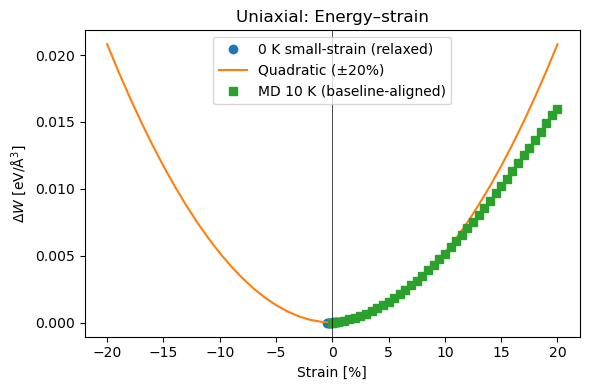

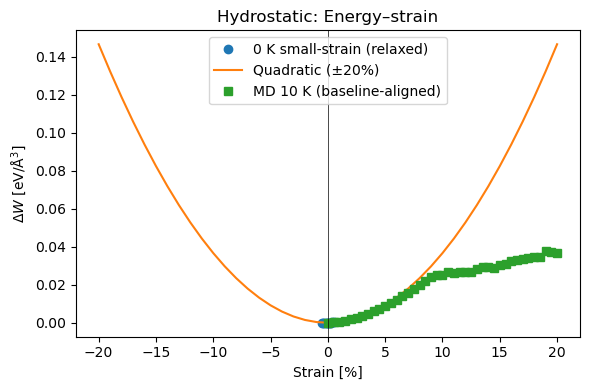

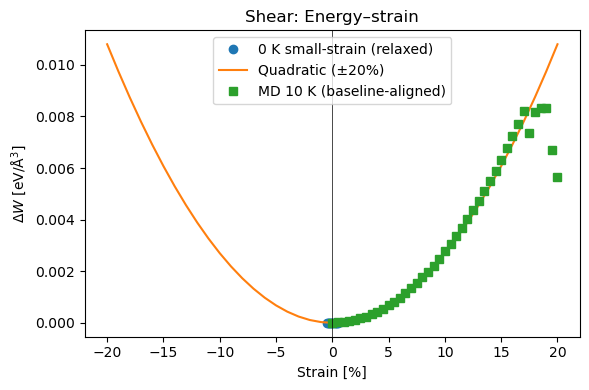

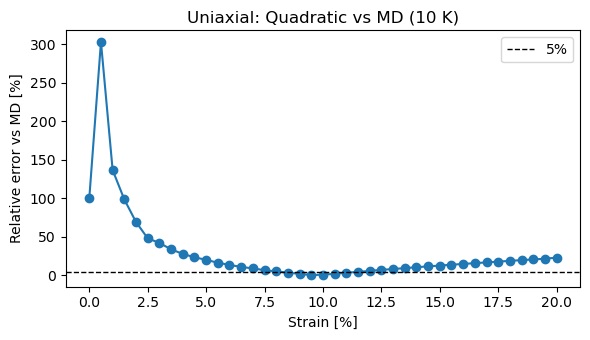

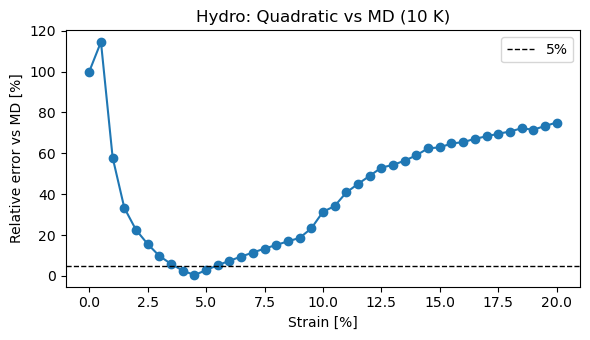

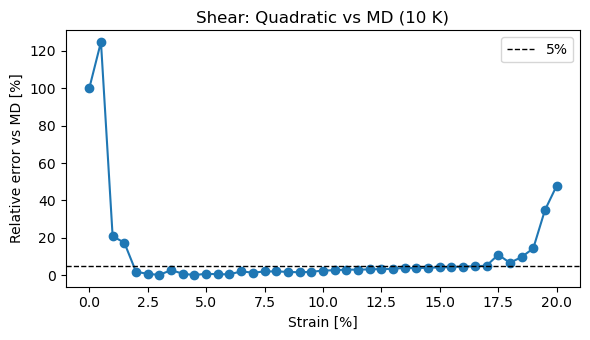


Summary:
Quadratic fit (0 K, ±0.5%) extrapolated to ±20% was compared with NVT MD at 10 K.
Within 5% deviation, validity extends to ~11.5% (uniaxial), ~5.0% (hydro), and ~16.5% (shear).


In [22]:
# Task 3.6

import time
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase import units

# Calculator factory (ASE EMT)
from ase.calculators.emt import EMT
def calc_factory():
    return EMT()

# Config
a0_guess   = 3.60
supercell  = (4, 4, 4)
fit_span   = 0.005         # ±0.5% for quadratic fit (0 K relaxed)
fit_points = 11
grid_large = np.linspace(-0.20, +0.20, 41)  # quadratic evaluation (±20%)
grid_md    = np.linspace(0.00,  0.20, 41)   # MD comparison grid (0..20%)

# MD params
T_MD         = 10          #  for near-0K MD
timestep_fs  = 2.0
eq_steps     = 800
sample_steps = 800
friction     = 0.01
fixcm        = False

# Error threshold
tol_rel = 0.05  # 5%

# Helpers
def energy_density(atoms, E0=None, V0=None):
    E = atoms.get_potential_energy(); V = atoms.get_volume()
    if E0 is None: E0 = E
    if V0 is None: V0 = V
    return (E - E0) / V0

def apply_uniaxial(atoms, eps):
    A = atoms.copy(); F = np.eye(3); F[0,0] = 1.0 + eps
    A.set_cell(A.cell.array @ F.T, scale_atoms=True)
    return A

def apply_hydrostatic(atoms, eps):
    A = atoms.copy(); F = (1.0 + eps) * np.eye(3)
    A.set_cell(A.cell.array @ F.T, scale_atoms=True)
    return A

def apply_simple_shear(atoms, gamma):
    A = atoms.copy(); F = np.eye(3); F[0,1] = gamma
    A.set_cell(A.cell.array @ F.T, scale_atoms=True)
    return A

def relax_positions_0K(atoms, fmax=1e-3, steps=400):
    B = atoms.copy()
    B.calc = calc_factory()
    BFGS(B, logfile=None).run(fmax=fmax, steps=steps)  # positional relax
    return B

def sample_W0_relaxed(atoms_ref, mode, grid, E0, V0):
    X, W = [], []
    for x in grid:
        if mode == 'uniaxial':   A = apply_uniaxial(atoms_ref, x)
        elif mode == 'hydro':    A = apply_hydrostatic(atoms_ref, x)
        elif mode == 'shear':    A = apply_simple_shear(atoms_ref, x)
        else: raise ValueError
        A = relax_positions_0K(A)
        X.append(x); W.append(energy_density(A, E0, V0))
    return np.array(X), np.array(W)

def fit_quadratic_even(X, W):
    X2 = X**2
    M  = np.vstack([np.ones_like(X2), X2]).T
    c0, c2 = np.linalg.lstsq(M, W, rcond=None)[0]
    return (c0, 0.0, c2)

def eval_poly(c, X):  # c1=0 enforced
    return c[0] + c[2]*X**2

def interp_on(x_src, y_src, x_tgt):
    try:
        from scipy.interpolate import interp1d
        return interp1d(x_src, y_src, kind='cubic', fill_value='extrapolate')(x_tgt)
    except Exception:
        return np.interp(x_tgt, x_src, y_src)

def rel_error(y_pred, y_true, eps=1e-12):
    denom = np.maximum(np.abs(y_pred), eps)
    return np.abs(y_pred - y_true) / denom

def validity_strain(strains, err_rel, tol=0.05):
    ok = strains[err_rel <= tol]
    return float(ok.max()) if ok.size else 0.0

# Reference (0 K relaxed) and small-strain quadratic
atoms0 = bulk('Cu', 'fcc', a=a0_guess).repeat(supercell)
atoms0.calc = calc_factory()
atoms0 = relax_positions_0K(atoms0)
E0 = atoms0.get_potential_energy(); V0 = atoms0.get_volume()
print(f"[Ref] Natoms={len(atoms0)}  V0={V0:.3f} Å^3  E0={E0:.6f} eV")

grid_fit = np.linspace(-fit_span, +fit_span, fit_points)
X_uni_fit,   W_uni_fit   = sample_W0_relaxed(atoms0, 'uniaxial', grid_fit, E0, V0)
X_hyd_fit,   W_hyd_fit   = sample_W0_relaxed(atoms0, 'hydro',    grid_fit, E0, V0)
X_shear_fit, W_shear_fit = sample_W0_relaxed(atoms0, 'shear',    grid_fit, E0, V0)

c_uni   = fit_quadratic_even(X_uni_fit,   W_uni_fit)
c_hyd   = fit_quadratic_even(X_hyd_fit,   W_hyd_fit)
c_shear = fit_quadratic_even(X_shear_fit, W_shear_fit)

W_uni_quad   = eval_poly(c_uni,   grid_large)
W_hyd_quad   = eval_poly(c_hyd,   grid_large)
W_shear_quad = eval_poly(c_shear, grid_large)

# MD at T_MD (NVT Langevin), 0..20% strain
def md_energy_vs_strain(atoms_ref, mode, Xlist, E0, V0, T=T_MD, verbose=True):
    edens = []
    for i, x in enumerate(Xlist, 1):
        if verbose: print(f"[MD] {mode}  ε={x*100:.1f}%  ({i}/{len(Xlist)})")
        if mode == 'uniaxial':   A = apply_uniaxial(atoms_ref, x)
        elif mode == 'hydro':    A = apply_hydrostatic(atoms_ref, x)
        elif mode == 'shear':    A = apply_simple_shear(atoms_ref, x)
        else: raise ValueError
        A.calc = calc_factory()
        # Initialize velocities and thermostat
        MaxwellBoltzmannDistribution(A, temperature_K=T)
        Stationary(A)
        dyn = Langevin(A, timestep_fs*units.fs, temperature_K=T, friction=friction, fixcm=fixcm)
        try:
            dyn.run(eq_steps)
            e_sum = 0.0
            for _ in range(sample_steps):
                dyn.run(1)
                e_sum += energy_density(A, E0, V0)
            edens.append(e_sum / sample_steps)
        except Exception as e:
            print(f"[Warn] MD failed at {x*100:.1f}% ({mode}): {e}. Recording NaN.")
            edens.append(np.nan)
    return np.array(edens)

t0 = time.perf_counter()
W_uni_md   = md_energy_vs_strain(atoms0, 'uniaxial', grid_md, E0, V0, T=T_MD, verbose=True)
W_hyd_md   = md_energy_vs_strain(atoms0, 'hydro',    grid_md, E0, V0, T=T_MD, verbose=True)
W_shear_md = md_energy_vs_strain(atoms0, 'shear',    grid_md, E0, V0, T=T_MD, verbose=True)
t1 = time.perf_counter()
print(f"[Timing] MD wall time: {t1 - t0:.1f} s")

# Baseline-align MD at ε = 0
def baseline_align(arr):
    if np.isnan(arr[0]):  # if even 0% failed, align to first finite value
        idx = np.where(~np.isnan(arr))[0]
        return arr - (arr[idx[0]] if idx.size else 0.0)
    return arr - arr[0]

W_uni_md   = baseline_align(W_uni_md)
W_hyd_md   = baseline_align(W_hyd_md)
W_shear_md = baseline_align(W_shear_md)

# Quadratic on the MD grid
W_uni_q_on_md   = interp_on(grid_large, W_uni_quad,   grid_md)
W_hyd_q_on_md   = interp_on(grid_large, W_hyd_quad,   grid_md)
W_shear_q_on_md = interp_on(grid_large, W_shear_quad, grid_md)

# Mask out failed MD points
mask_uni   = ~np.isnan(W_uni_md)
mask_hyd   = ~np.isnan(W_hyd_md)
mask_shear = ~np.isnan(W_shear_md)

# Errors and validity
err_uni   = rel_error(W_uni_q_on_md[mask_uni],   W_uni_md[mask_uni])
err_hyd   = rel_error(W_hyd_q_on_md[mask_hyd],   W_hyd_md[mask_hyd])
err_shear = rel_error(W_shear_q_on_md[mask_shear], W_shear_md[mask_shear])

eps_valid_uni   = validity_strain(grid_md[mask_uni],   err_uni,   tol=tol_rel) if mask_uni.any()   else 0.0
eps_valid_hyd   = validity_strain(grid_md[mask_hyd],   err_hyd,   tol=tol_rel) if mask_hyd.any()   else 0.0
eps_valid_shear = validity_strain(grid_md[mask_shear], err_shear, tol=tol_rel) if mask_shear.any() else 0.0

print(f"\nValidity vs MD at T={T_MD} K (≤{int(tol_rel*100)}% rel. error):")
print(f"  Uniaxial  : ~{eps_valid_uni*100:.1f}%")
print(f"  Hydro     : ~{eps_valid_hyd*100:.1f}%")
print(f"  Shear γ   : ~{eps_valid_shear*100:.1f}%")

# Plots
def panel_energy(mode, X_fit, W_fit, X_large, W_quad, X_md, W_md, Tlabel):
    plt.figure(figsize=(6,4))
    plt.plot(X_fit*100,   W_fit,  'o', label='0 K small-strain (relaxed)')
    plt.plot(X_large*100, W_quad, '-', label='Quadratic (±20%)')
    plt.plot(X_md[~np.isnan(W_md)]*100,  W_md[~np.isnan(W_md)],  's', label=f'MD {Tlabel} (baseline-aligned)')
    plt.axvline(0, color='k', lw=0.5)
    plt.xlabel('Strain [%]'); plt.ylabel(r'$\Delta W$ [eV/$\mathrm{\AA}^3$]')
    plt.title(f'{mode}: Energy–strain')
    plt.legend(); plt.tight_layout(); plt.show()

def panel_error(mode, X_md, W_q_on_md, W_md, Tlabel):
    m = ~np.isnan(W_md)
    if not m.any():
        print(f"[Info] No valid MD points for {mode}.")
        return
    err = rel_error(W_q_on_md[m], W_md[m])
    plt.figure(figsize=(6,3.5))
    plt.plot(X_md[m]*100, err*100, 'o-')
    plt.axhline(tol_rel*100, color='k', ls='--', lw=1, label=f'{int(tol_rel*100)}%')
    plt.xlabel('Strain [%]'); plt.ylabel('Relative error vs MD [%]')
    plt.title(f'{mode}: Quadratic vs MD ({Tlabel})')
    plt.legend(); plt.tight_layout(); plt.show()

panel_energy("Uniaxial",   X_uni_fit,   W_uni_fit,   grid_large, W_uni_quad,   grid_md, W_uni_md,   f"{T_MD} K")
panel_energy("Hydrostatic",X_hyd_fit,   W_hyd_fit,   grid_large, W_hyd_quad,   grid_md, W_hyd_md,   f"{T_MD} K")
panel_energy("Shear",      X_shear_fit, W_shear_fit, grid_large, W_shear_quad, grid_md, W_shear_md, f"{T_MD} K")

panel_error("Uniaxial",   grid_md, W_uni_q_on_md,   W_uni_md,   f"{T_MD} K")
panel_error("Hydro",      grid_md, W_hyd_q_on_md,   W_hyd_md,   f"{T_MD} K")
panel_error("Shear",      grid_md, W_shear_q_on_md, W_shear_md, f"{T_MD} K")

# Summary
print("\nSummary:")
print(f"Quadratic fit (0 K, ±{fit_span*100:.1f}%) extrapolated to ±20% was compared with NVT MD at {T_MD} K.")
print(f"Within {int(tol_rel*100)}% deviation, validity extends to ~{eps_valid_uni*100:.1f}% (uniaxial), "
      f"~{eps_valid_hyd*100:.1f}% (hydro), and ~{eps_valid_shear*100:.1f}% (shear).")
